In [1]:
import pymc as pm
import numpy as np
import pandas as pd
import arviz as az
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("rainfall.csv")


In [2]:
# Prepare the data
X_temp = df["temparature"].values
X_cloud = df["cloud"].values
y_rain = df["rainfall"].values

# Standardize predictors for better sampling
X_temp_std = (X_temp - X_temp.mean()) / X_temp.std()
X_cloud_std = (X_cloud - X_cloud.mean()) / X_cloud.std()

with pm.Model() as logistic_model:
    # Priors
    beta_0 = pm.Normal("beta_0", mu=0, sigma=1)
    beta_temp = pm.Normal("beta_temp", mu=0, sigma=1)
    beta_cloud = pm.Normal("beta_cloud", mu=0, sigma=1)

    # Linear combination and logit link
    logit_p = beta_0 + beta_temp * X_temp + beta_cloud * X_cloud
    p = pm.Deterministic("p", pm.math.sigmoid(logit_p))

    # Likelihood
    y_obs = pm.Bernoulli("y_obs", p=p, observed=y_rain)

    # Sampling
    trace_logistic = pm.sample(2000, tune=2000, target_accept=0.95, return_inferencedata=True)

# Summarize posterior estimates
az.summary(trace_logistic, var_names=["beta_0", "beta_temp", "beta_cloud"])

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta_0, beta_temp, beta_cloud]


Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 90 seconds.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta_0,-6.326,0.465,-7.215,-5.462,0.011,0.008,1722.0,2061.0,1.0
beta_temp,0.039,0.013,0.014,0.062,0.000,0.000,2014.0,2003.0,1.0
beta_cloud,0.091,0.004,0.084,0.098,0.000,0.000,2219.0,2629.0,1.0


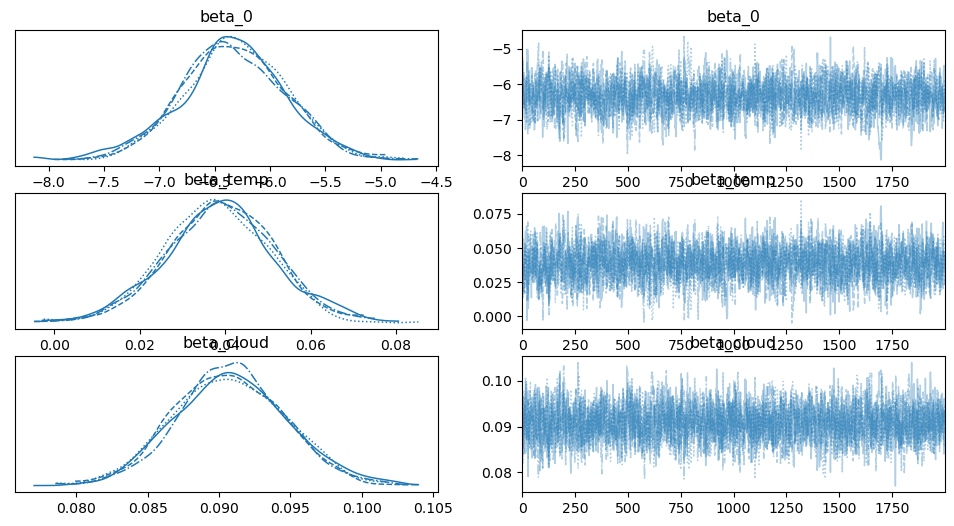

In [3]:
az.plot_trace(trace_logistic,var_names=["beta_0", "beta_temp", "beta_cloud"])
plt.show()